# 📊 SALES INSIGHTS DASHBOARD

## 🟢 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 🟢 2️⃣ Connect to MySQL & Load Data

In [4]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="1928",
    database="sales_db"
)

query = "SELECT * FROM orders"
df = pd.read_sql(query, conn)

df.head()

C:\Users\Askhay\AppData\Local\Temp\ipykernel_230564\4226691156.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


## 🟢 3️⃣ Data Overview

In [7]:
df.shape

(9800, 18)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9800 non-null   str    
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(1), int6

In [11]:
df.describe()

,Row_ID,Sales
count,9800.000000,9800.000000
mean,4900.500000,230.769079
std,2829.160653,626.651906
min,1.000000,0.440000
25%,2450.750000,17.250000
50%,4900.500000,54.490000
75%,7350.250000,210.605000
max,9800.000000,22638.480000


## 🟢 4️⃣ Data Preprocessing

In [14]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

In [16]:
df.isnull().sum()

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
Year             0
Month            0
dtype: int64

## 🟢 5️⃣ KPI Analysis

### 💰 Total Revenue

In [20]:
total_revenue = df['Sales'].sum()
total_orders = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
avg_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 2261536.97
Total Orders: 4922
Total Customers: 793
Average Order Value: 459.48


## 🟢 6️⃣ Revenue by Category

In [23]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.94
Furniture          728658.75
Office Supplies    705422.28
Name: Sales, dtype: float64

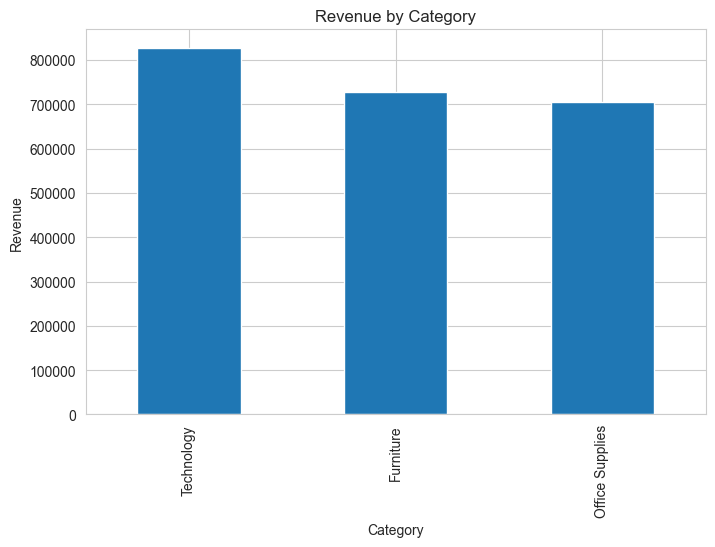

In [25]:
category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

## 🟢 7️⃣ Revenue by Region

In [28]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

Region
West       710219.77
East       669518.85
Central    492646.90
South      389151.45
Name: Sales, dtype: float64

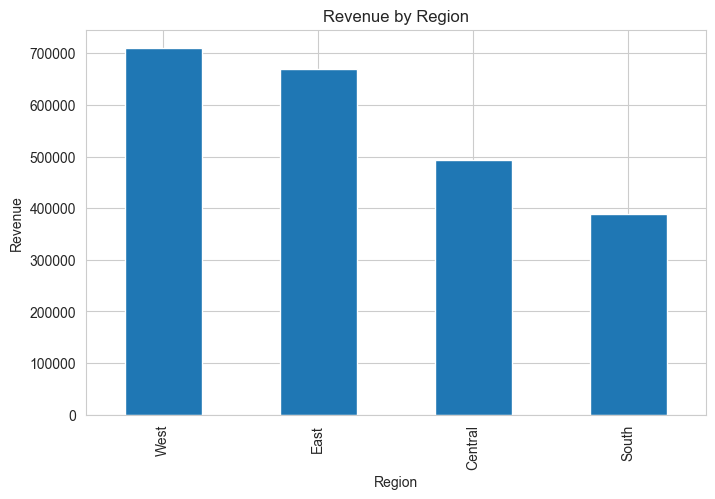

In [30]:
region_sales.plot(kind='bar', figsize=(8,5))
plt.title("Revenue by Region")
plt.ylabel("Revenue")
plt.show()

## 🟢 8️⃣ Monthly Sales Trend

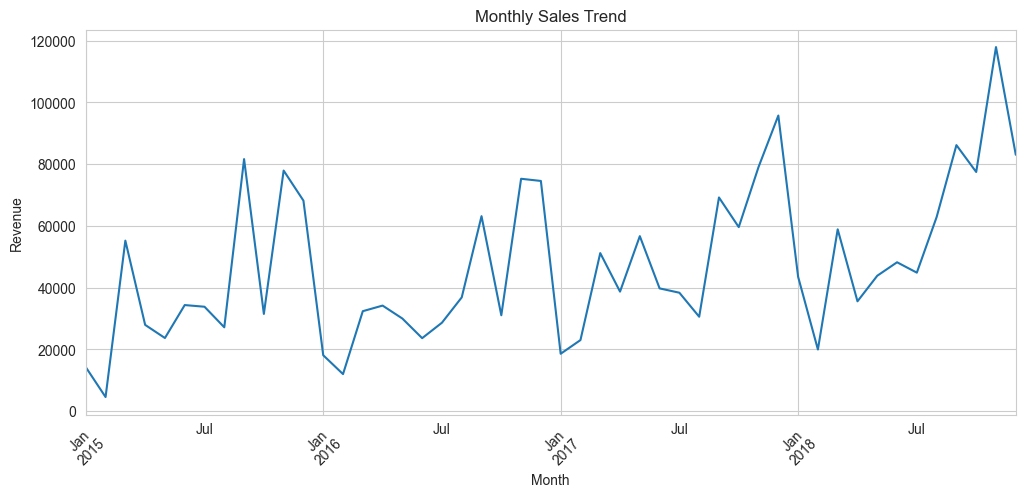

In [33]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## 🟢 9️⃣ Top 10 Customers

In [36]:
top_customers = (
    df.groupby('Customer_Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer_Name
Sean Miller           25043.07
Tamara Chand          19052.22
Raymond Buch          15117.35
Tom Ashbrook          14595.62
Adrian Barton         14473.57
Ken Lonsdale          14175.23
Sanjit Chand          14142.34
Hunter Lopez          12873.30
Sanjit Engle          12209.44
Christopher Conant    12129.08
Name: Sales, dtype: float64

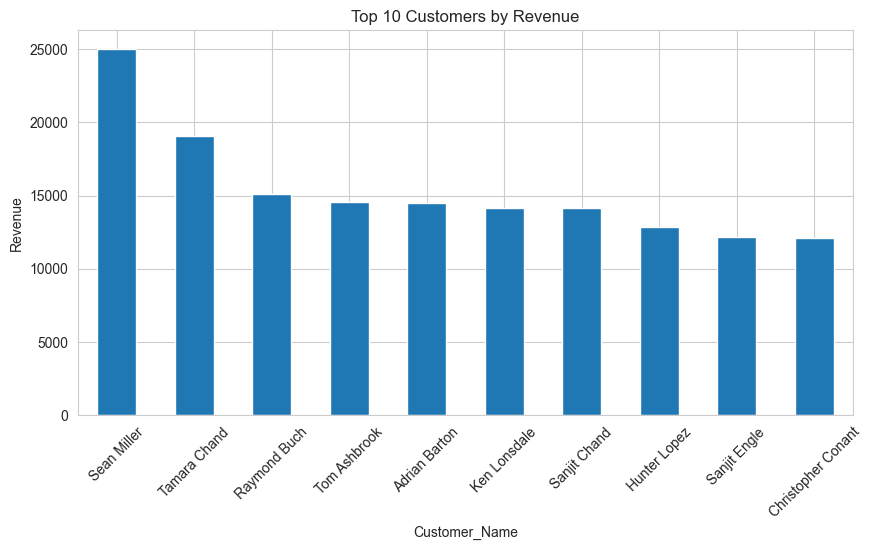

In [38]:
top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## 🟢 🔟 Customer Segmentation 

In [41]:
customer_sales = df.groupby('Customer_ID')['Sales'].sum()

segments = pd.qcut(customer_sales, q=3, labels=['Low Value', 'Medium Value', 'High Value'])

customer_segment = pd.DataFrame({
    'Total_Sales': customer_sales,
    'Segment': segments
})

customer_segment.head()

,Total_Sales,Segment
Customer_ID,,
AA-10315,5563.56,High Value
AA-10375,1056.39,Low Value
AA-10480,1790.51,Medium Value
AA-10645,5086.94,High Value
AB-10015,886.15,Low Value


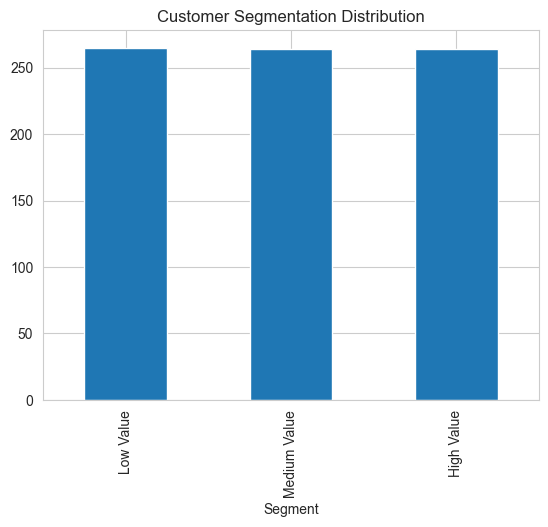

In [43]:
customer_segment['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segmentation Distribution")
plt.show()

## 🟢 1️⃣1️⃣ Repeat vs One-Time Customers

In [46]:
order_count = df.groupby('Customer_ID')['Order_ID'].nunique()

repeat_customers = (order_count > 1).sum()
one_time_customers = (order_count == 1).sum()

print("Repeat Customers:", repeat_customers)
print("One-time Customers:", one_time_customers)

Repeat Customers: 780
One-time Customers: 13


## 🟢 1️⃣2️⃣ Category vs Region Heatmap

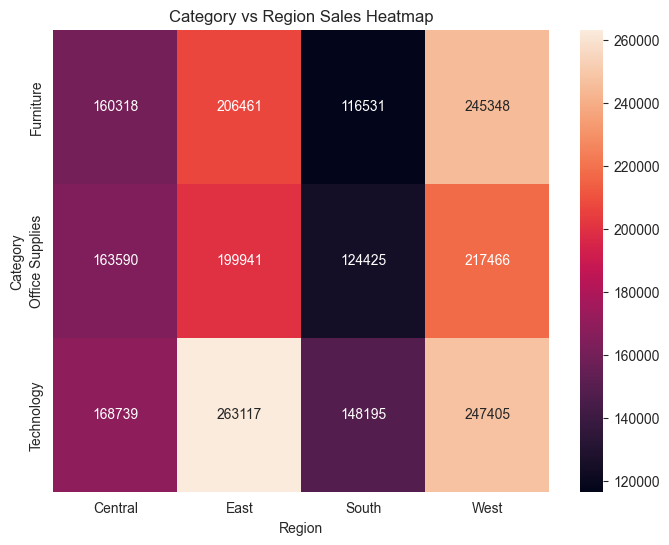

In [49]:
pivot_table = df.pivot_table(
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc='sum'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt=".0f")
plt.title("Category vs Region Sales Heatmap")
plt.show()

## 🟢 1️⃣3️⃣ Sales Distribution Analysis

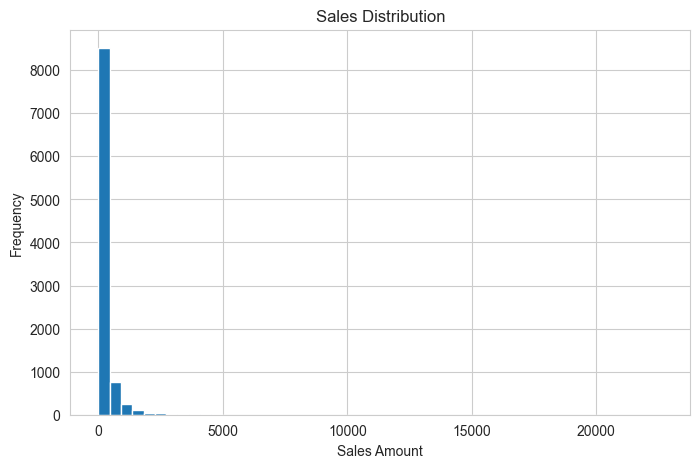

In [54]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()

## 🟢 1️⃣4️⃣ Yearly Growth Rate

In [57]:
yearly_sales = df.groupby('Year')['Sales'].sum()
growth_rate = yearly_sales.pct_change() * 100

growth_rate

Year
2015          NaN
2016    -4.255510
2017    30.636885
2018    20.303336
Name: Sales, dtype: float64

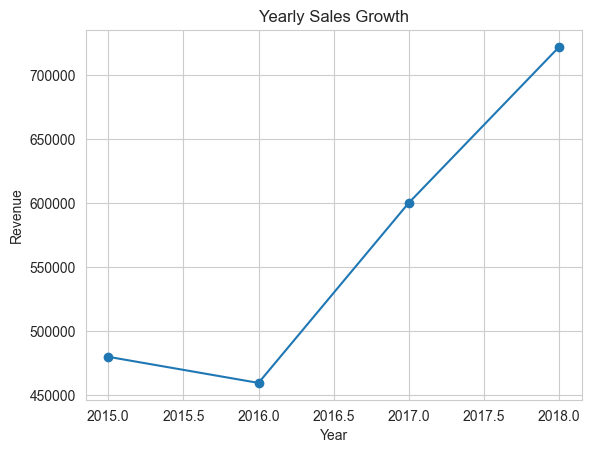

In [59]:
yearly_sales.plot(marker='o')
plt.title("Yearly Sales Growth")
plt.ylabel("Revenue")
plt.show()

# 🟢 1️⃣5️⃣ Key Business Insights

### 📌 Key Business Insights

   *  Technology category generates highest revenue.

   *  High-value customers contribute majority of revenue.

   *  West region dominates overall performance.

   *  Significant one-time customers → retention opportunity.

   *  Sales show consistent year-over-year growth.

# 🟢 1️⃣6️⃣ Business Recommendations

### 🎯 Recommendations

   *  Focus retention campaigns on medium-value customers.

   *  Strengthen marketing in low-performing regions.

   *  Upsell high-margin categories.

   *  Improve loyalty programs for repeat purchases.